# 10 — Web Scraping: Books to Scrape

**Objective:** Collect at least 50 publicly accessible book records, save them to CSV, and prepare the dataset for analysis.

**Practice website:** [Books to Scrape](https://books.toscrape.com/), a site intended for web-scraping practice. Always check a site's terms, robots.txt, and access rules before scraping other websites. This notebook uses a small delay between requests and does not attempt to bypass access controls.

**Fields collected:** title, price, availability, rating, product URL, and category.

## 1. Install and Import Libraries
If needed, uncomment the pip command and run it in your notebook environment.

In [1]:
# %pip install requests beautifulsoup4 pandas matplotlib seaborn

import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from pathlib import Path

sns.set_theme(style="whitegrid")
BASE_URL = "https://books.toscrape.com/"
HEADERS = {"User-Agent": "EducationalDataScienceAssignment/1.0 (polite practice scraper)"}

session = requests.Session()
session.headers.update(HEADERS)

response = session.get(BASE_URL, timeout=20)
response.raise_for_status()
print("Website reachable. HTTP status:", response.status_code)

Website reachable. HTTP status: 200


## 2. Inspect One Page
First inspect the page structure and locate book cards. The site uses `article.product_pod` for each listing.

In [2]:
soup = BeautifulSoup(response.text, "html.parser")
book_cards = soup.select("article.product_pod")
print("Book cards found on page:", len(book_cards))
print("First book title:", book_cards[0].h3.a["title"] if book_cards else "No cards found")

Book cards found on page: 20
First book title: A Light in the Attic


## 3. Define a Page Parser
The helper below extracts fields from one listing page. Rating labels are converted to a numeric 1–5 value.

In [4]:
RATING_MAP = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

def parse_listing_page(html, page_url):
    page_soup = BeautifulSoup(html, "html.parser")
    records = []

    for card in page_soup.select("article.product_pod"):
        title = card.h3.a.get("title", "").strip()
        relative_url = card.h3.a.get("href", "")
        product_url = urljoin(page_url, relative_url)

        price_text = card.select_one(".price_color").get_text(strip=True)
        price_value = float(price_text.replace("£", "").replace("Â", "").strip())

        availability = card.select_one(".availability").get_text(" ", strip=True)
        rating_word = next(
            (cls for cls in card.select_one("p.star-rating").get("class", []) if cls != "star-rating"),
            None
        )
        rating = RATING_MAP.get(rating_word)

        records.append({
            "title": title,
            "price_gbp": price_value,
            "availability": availability,
            "rating": rating,
            "product_url": product_url
        })

    return records

## 4. Scrape Multiple Pages (50+ Records)
The script follows the site's `next` link until it has at least 50 records or there are no more pages. A short pause is included between page requests.

In [5]:
TARGET_RECORDS = 50
all_records = []
next_url = BASE_URL
pages_scraped = 0

while next_url and len(all_records) < TARGET_RECORDS:
    page_response = session.get(next_url, timeout=20)
    page_response.raise_for_status()

    page_records = parse_listing_page(page_response.text, next_url)
    all_records.extend(page_records)
    pages_scraped += 1

    page_soup = BeautifulSoup(page_response.text, "html.parser")
    next_link = page_soup.select_one("li.next a")
    next_url = urljoin(next_url, next_link["href"]) if next_link else None

    print(f"Pages scraped: {pages_scraped} | Records collected: {len(all_records)}")
    if next_url and len(all_records) < TARGET_RECORDS:
        time.sleep(1)  # polite delay between requests

scraped_df = pd.DataFrame(all_records).drop_duplicates(subset=["product_url"]).head(TARGET_RECORDS)
print("Unique records collected:", len(scraped_df))
if len(scraped_df) < TARGET_RECORDS:
    print("Note: Fewer than 50 unique records were collected. Check site/network availability.")
display(scraped_df.head())

Pages scraped: 1 | Records collected: 20
Pages scraped: 2 | Records collected: 40
Pages scraped: 3 | Records collected: 60
Unique records collected: 50


,title,price_gbp,availability,rating,product_url
0,A Light in the Attic,51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...


## 5. Validate and Save the Scraped Dataset
Check row count, duplicate URLs, missing values, and data types before saving.

In [8]:
print("Dataset shape:", scraped_df.shape)
print("Duplicate product URLs:", scraped_df["product_url"].duplicated().sum())
display(scraped_df.isna().sum().rename("missing_values").to_frame())
display(scraped_df.dtypes.rename("data_type").to_frame())

output_dir = Path("data")
output_dir.mkdir(exist_ok=True)
csv_path = output_dir / "books_scraped.csv"
scraped_df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"Saved {len(scraped_df)} records to: {csv_path.resolve()}")

Dataset shape: (50, 5)
Duplicate product URLs: 0


,missing_values
title,0
price_gbp,0
availability,0
rating,0
product_url,0


,data_type
title,object
price_gbp,float64
availability,object
rating,int64
product_url,object


Saved 50 records to: /content/data/books_scraped.csv


## 6. Analyze the Scraped Data
These summaries and charts demonstrate how collected web data can be explored.

,price_gbp,rating
count,50.00,50.00
mean,35.14,3.12
std,14.11,1.48
min,12.84,1.00
25%,22.61,2.00
50%,34.08,3.00
75%,49.53,4.75
max,57.31,5.00


Availability values:


,count
availability,
In stock,50


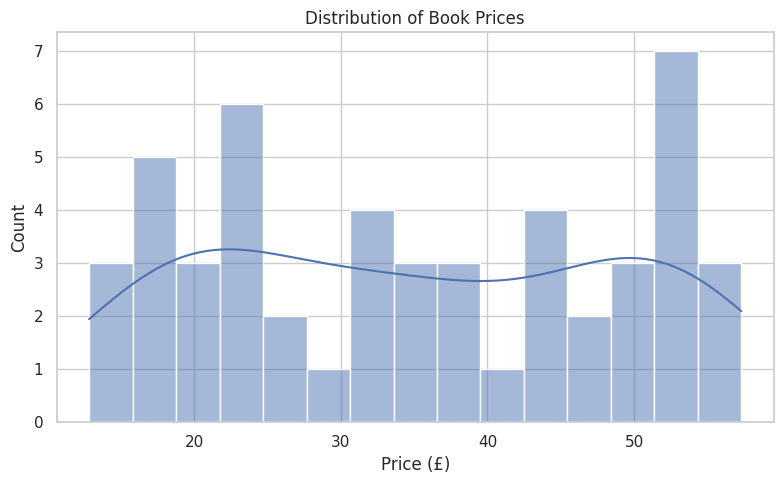

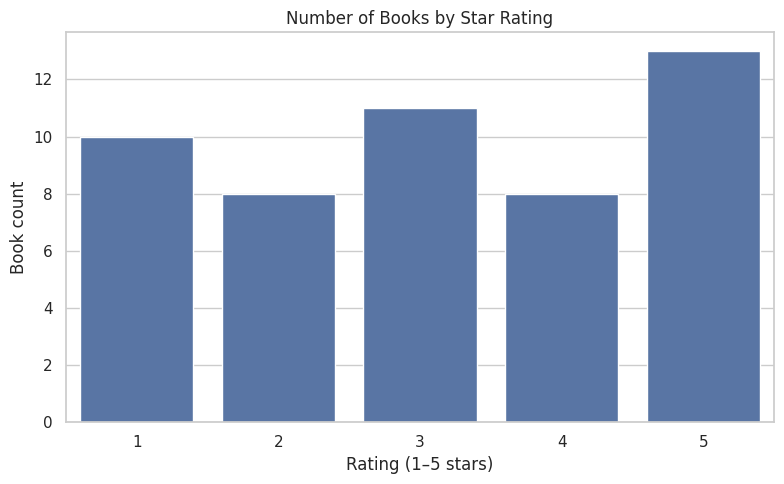

In [9]:
display(scraped_df[["price_gbp", "rating"]].describe().round(2))
print("Availability values:")
display(scraped_df["availability"].value_counts().to_frame("count"))

plt.figure(figsize=(8, 5))
sns.histplot(data=scraped_df, x="price_gbp", bins=15, kde=True)
plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=scraped_df, x="rating", order=[1, 2, 3, 4, 5])
plt.title("Number of Books by Star Rating")
plt.xlabel("Rating (1–5 stars)")
plt.ylabel("Book count")
plt.tight_layout()
plt.show()